In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [17]:
folder_path = "../results/metrics"

In [18]:
video_severity = {
    "metrics_1": "moderate",
    "metrics_2": "severe",
    "metrics_3": "severe",
    "metrics_4": "severe",
    "metrics_5": "severe",
    "metrics_6": "severe",
    "metrics_7": "severe",
    "metrics_8": "severe",
    "metrics_9": "mild",
    "metrics_10": "moderate",
    "metrics_11": "moderate",
    "metrics_12": "severe",
    "metrics_13": "moderate"
}

In [19]:
all_metrics = []
for filename in os.listdir(folder_path):
    if filename.endswith(".csv") and filename.startswith("metrics_"):
        file_id = filename.split(".")[0]  # e.g., 'metrics_1'
        severity = video_severity.get(file_id, "unknown")
        df = pd.read_csv(os.path.join(folder_path, filename))
        df["Video"] = file_id
        df["Severity"] = severity
        all_metrics.append(df)

In [20]:
df_all = pd.concat(all_metrics, ignore_index=True)

In [21]:
df_long = df_all.melt(
    id_vars=["Video", "Metric", "Severity"],
    value_vars=["Raw", "Cleaned", "No Fillers"],
    var_name="Version",
    value_name="Score"
)

In [22]:
grouped_avg = df_long.groupby(["Severity", "Metric", "Version"]).mean(numeric_only=True).reset_index()


In [23]:
summary_table = grouped_avg.pivot_table(
    index=["Metric", "Version"],
    columns="Severity",
    values="Score"
)

In [24]:
print("Average Metrics by Severity:")
display(summary_table)  # or just: summary_table.head()

Average Metrics by Severity:


Severity                             mild  moderate    severe
Metric                  Version                              
BERTScore F1            Cleaned     0.658   0.53050  0.421625
                        No Fillers  0.880   0.78775  0.484375
                        Raw         0.685   0.43475  0.283250
BERTScore Precision     Cleaned     0.743   0.67725  0.490250
                        No Fillers  0.886   0.81825  0.521000
                        Raw         0.773   0.56775  0.363000
BERTScore Recall        Cleaned     0.573   0.39700  0.355750
                        No Fillers  0.874   0.75700  0.448500
                        Raw         0.599   0.30925  0.207625
Content Word Accuracy   Cleaned     0.964   0.95550  0.711875
                        No Fillers  0.964   0.95050  0.700875
                        Raw         1.000   0.89775  0.646250
Content Word Precision  Cleaned     1.000   0.93675  0.710000
                        No Fillers  1.000   0.95725  0.720625
                        Raw         1.000   0.92125  0.689000
Content Word Recall     Cleaned     0.964   0.95550  0.711875
                        No Fillers  0.964   0.95050  0.700875
                        Raw         1.000   0.89775  0.646250
Levenshtein Match Ratio Cleaned     0.631   0.42450  0.514125
                        No Fillers  0.778   0.68350  0.632875
                        Raw         0.440   0.37725  0.339375
Match Error Rate (MER)  Cleaned     0.182   0.31350  0.448625
                        No Fillers  0.069   0.14375  0.398750
                        Raw         0.397   0.63450  0.753250
Semantic Similarity     Cleaned     0.959   0.88025  0.722125
                        No Fillers  0.992   0.96125  0.728125
                        Raw         0.950   0.83200  0.661750
Word Error Rate (WER)   Cleaned     0.184   0.31350  0.501000
                        No Fillers  0.070   0.14475  0.475625
                        Raw         0.397   0.63450  0.817375

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\3232151644.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=severity_counts, x='Severity', y='Count', palette='Set2')


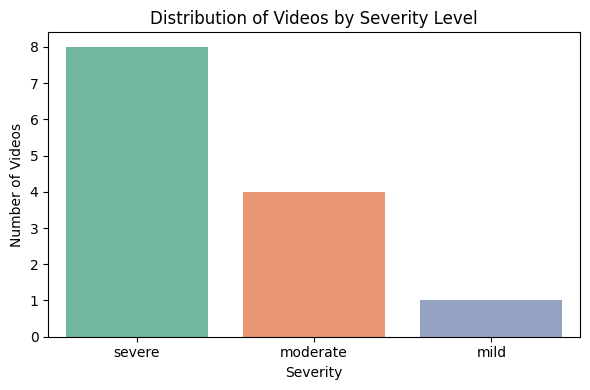

In [25]:
# Convert video_severity dict to DataFrame
severity_df = pd.DataFrame.from_dict(video_severity, orient='index', columns=['Severity'])
severity_counts = severity_df['Severity'].value_counts().reset_index()
severity_counts.columns = ['Severity', 'Count']

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=severity_counts, x='Severity', y='Count', palette='Set2')
plt.title('Distribution of Videos by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Number of Videos')
plt.tight_layout()
plt.savefig("../results/vis/severity_distribution.png", dpi=300)
plt.show()

In [28]:
error_metrics = ["Word Error Rate (WER)", "Match Error Rate (MER)"]
positive_metrics = [
        "Semantic Similarity", "Levenshtein Match Ratio", "Content Word Accuracy",
        "Content Word Precision", "Content Word Recall", "BERTScore Precision",
        "BERTScore Recall", "BERTScore F1"
    ]

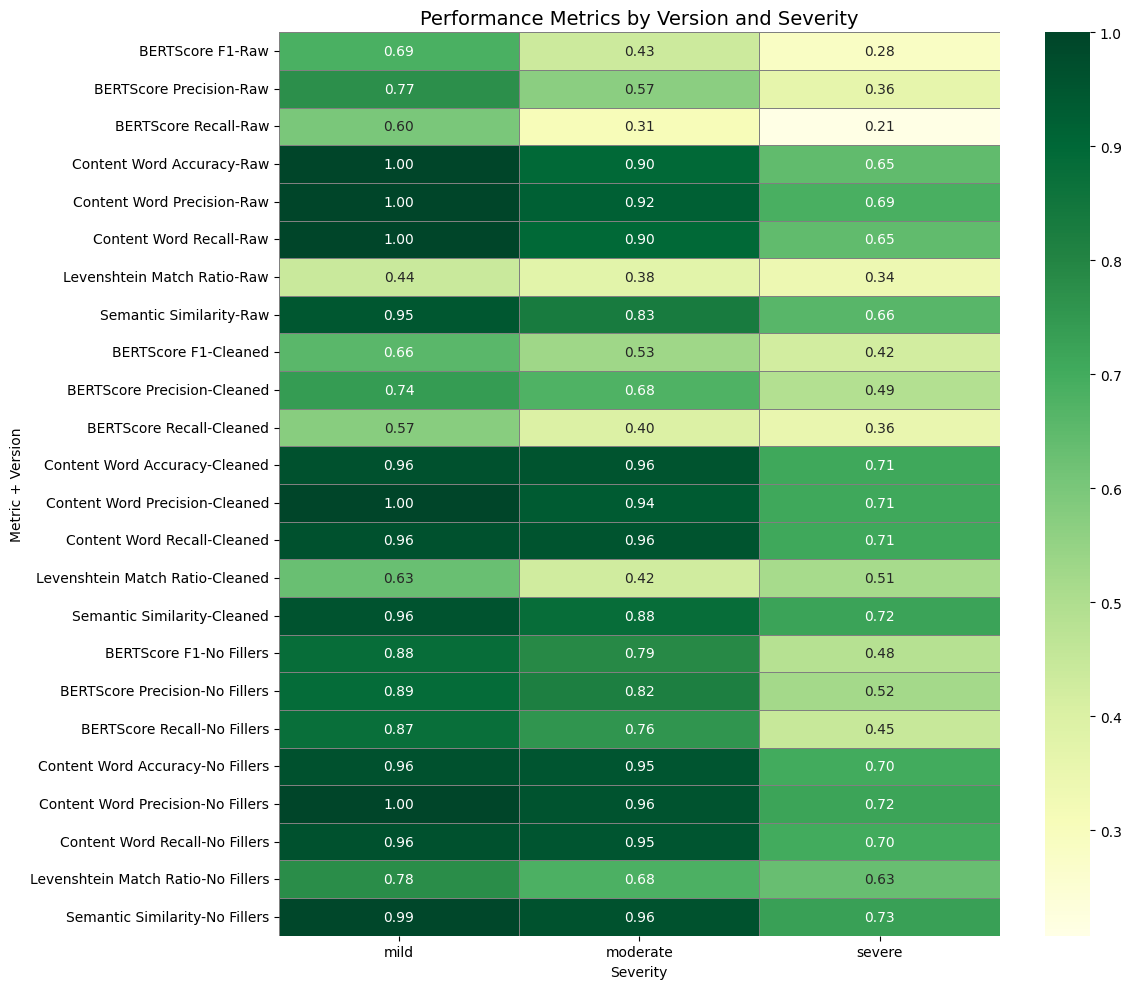

In [29]:
# Convert MultiIndex into columns
positive_df = summary_table.copy().loc[
    summary_table.index.get_level_values("Metric").isin(positive_metrics)
].reset_index()

# Sort version order as categorical
version_order = ["Raw", "Cleaned", "No Fillers"]
positive_df["Version"] = pd.Categorical(positive_df["Version"], categories=version_order, ordered=True)

# Sort first by Version, then by Metric
positive_df = positive_df.sort_values(["Version", "Metric"])

# Set MultiIndex again
positive_df = positive_df.set_index(["Metric", "Version"])

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    positive_df,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Performance Metrics by Version and Severity", fontsize=14)
plt.xlabel("Severity")
plt.ylabel("Metric + Version")
plt.tight_layout()
plt.savefig("../results/vis/performance_metrics_heatmap.png", dpi=300)
plt.show()

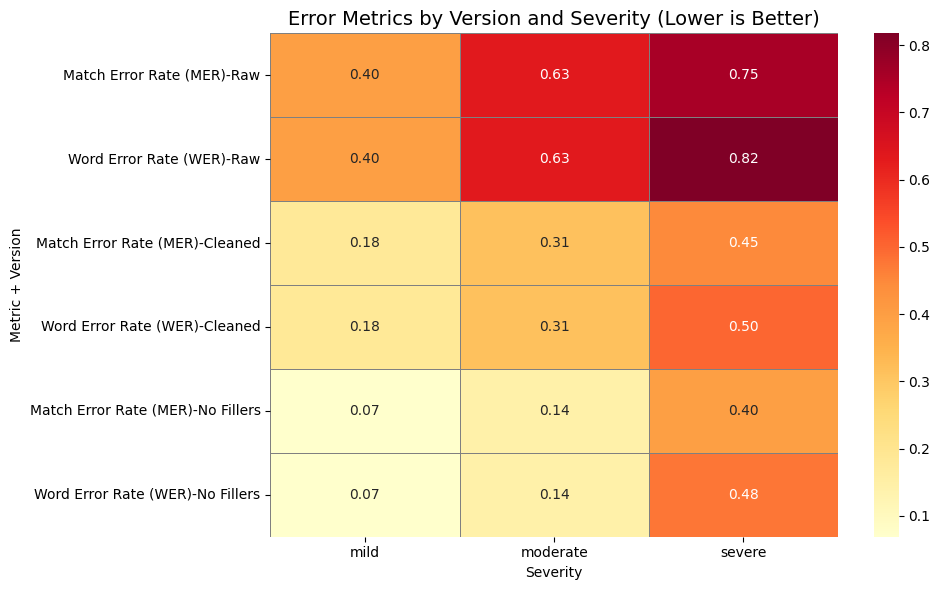

In [30]:
# Step 1: Define your error metrics
error_metrics = [
    "Word Error Rate (WER)",
    "Match Error Rate (MER)"
]

# Step 2: Filter and reset index
error_df = summary_table.copy().loc[
    summary_table.index.get_level_values("Metric").isin(error_metrics)
].reset_index()

# Step 3: Set version sort order
version_order = ["Raw", "Cleaned", "No Fillers"]
error_df["Version"] = pd.Categorical(error_df["Version"], categories=version_order, ordered=True)

# Step 4: Sort by version and metric
error_df = error_df.sort_values(["Version", "Metric"])

# Step 5: Set index back to (Metric, Version)
error_df = error_df.set_index(["Metric", "Version"])

# Step 6: Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(
    error_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",  # Yellow to Red (low = good, high = bad)
    linewidths=0.5,
    linecolor='gray'
)
plt.title("Error Metrics by Version and Severity (Lower is Better)", fontsize=14)
plt.xlabel("Severity")
plt.ylabel("Metric + Version")
plt.tight_layout()
plt.savefig("../results/vis/errors_heatmap.png", dpi=300)
plt.show()


In [31]:
# 2. Select only No Fillers version (best-case version)
df_nf = df_long[df_long["Version"] == "No Fillers"].copy()

# 3. Normalize all scores (0–1) per metric
from sklearn.preprocessing import MinMaxScaler

# Pivot to wide format
df_nf_wide = df_nf.pivot(index="Video", columns="Metric", values="Score")

# Normalize and invert errors
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_nf_wide), 
                             columns=df_nf_wide.columns,
                             index=df_nf_wide.index)

# Invert error metrics so higher = better
df_normalized[error_metrics] = 1 - df_normalized[error_metrics]

# 4. Compute composite score
df_normalized["Composite Score"] = df_normalized.mean(axis=1)

# 5. Sort and print best/worst
best_video = df_normalized["Composite Score"].sort_values(ascending=False).head(1)
worst_video = df_normalized["Composite Score"].sort_values(ascending=False).tail(1)

print("Top Performing Video (No Fillers):")
print(best_video)

print("\nWorst Performing Video (No Fillers):")
print(worst_video)

Top Performing Video (No Fillers):
Video
metrics_13    1.0
Name: Composite Score, dtype: float64

Worst Performing Video (No Fillers):
Video
metrics_2    0.097651
Name: Composite Score, dtype: float64


In [32]:
df_normalized

Metric,BERTScore F1,BERTScore Precision,BERTScore Recall,Content Word Accuracy,Content Word Precision,Content Word Recall,Levenshtein Match Ratio,Match Error Rate (MER),Semantic Similarity,Word Error Rate (WER),Composite Score
Video,,,,,,,,,,,
metrics_1,0.757794,0.777778,0.791873,0.81625,0.804571,0.81625,0.000000,0.797015,0.888724,8.814879e-01,0.733174
metrics_10,0.733813,0.808706,0.726462,1.00000,1.000000,1.00000,0.725753,0.808955,0.937685,8.892734e-01,0.863065
metrics_11,0.711031,0.805269,0.692765,0.93625,1.000000,0.93625,0.929766,0.798507,0.949555,8.806228e-01,0.864002
metrics_12,0.824940,0.840779,0.848365,0.87500,1.000000,0.87500,0.908584,0.794030,0.903561,8.737024e-01,0.874396
metrics_13,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000e+00,1.000000
metrics_2,0.123501,0.210767,0.232904,0.00000,0.000000,0.00000,0.020067,0.000000,0.000000,3.892734e-01,0.097651
metrics_3,0.025180,0.309278,0.000000,0.58375,0.771429,0.58375,0.664437,0.147761,0.443620,5.060554e-01,0.403526
metrics_4,0.000000,0.000000,0.211100,0.58375,0.314286,0.58375,0.497213,0.070149,0.152819,1.110223e-16,0.241307
metrics_5,0.570743,0.660939,0.584737,0.61000,0.824000,0.61000,0.881828,0.614925,0.805638,7.768166e-01,0.693963


In [33]:
best_scores

NameError: name 'best_scores' is not defined

In [34]:
# Convert to numeric (float) just in case
best_scores = pd.to_numeric(df_normalized.loc[best_video_name, metrics], errors='coerce').values
worst_scores = pd.to_numeric(df_normalized.loc[worst_video_name, metrics], errors='coerce').values

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, best_scores, width, label=f'{best_video_name} (Best)', color='green')
ax.bar(x + width/2, worst_scores, width, label=f'{worst_video_name} (Worst)', color='red')

ax.set_ylabel('Normalized Score (Higher = Better)')
ax.set_title('Metric Comparison: Best vs Worst Video (No Fillers)')
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("../results/vis/best_worst.png", dpi=300)
plt.show()

NameError: name 'best_video_name' is not defined

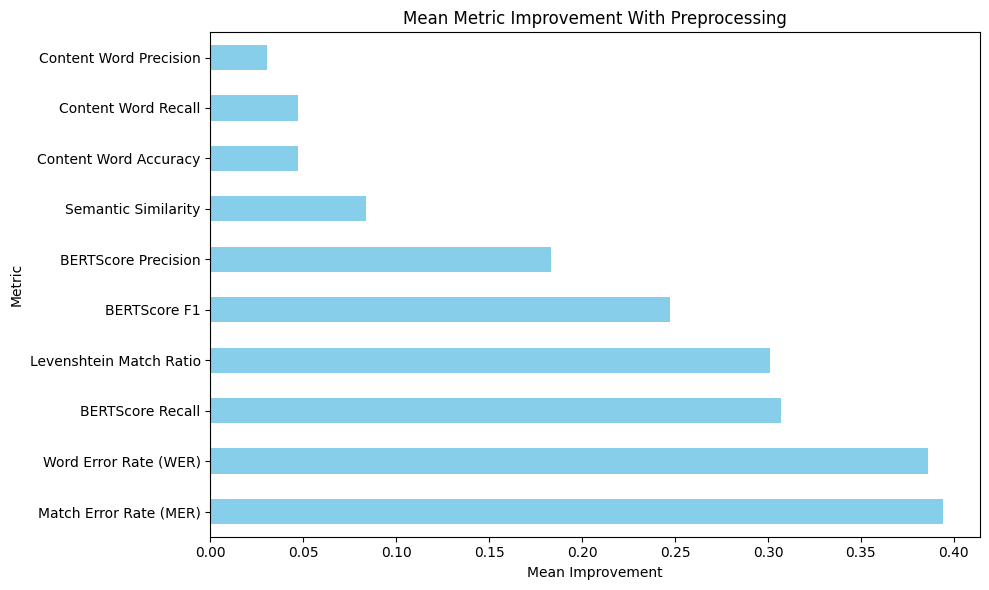

In [38]:
# 1. Compute improvement from Raw to No Fillers
df_wide = df_long.pivot(index=["Video", "Metric"], columns="Version", values="Score").reset_index()
df_wide["Improvement"] = df_wide["No Fillers"] - df_wide["Raw"]

# 2. Invert improvement for error metrics (lower is better → negate difference)
error_metrics = ["Word Error Rate (WER)", "Match Error Rate (MER)"]
df_wide.loc[df_wide["Metric"].isin(error_metrics), "Improvement"] *= -1

# 3. Compute average improvement per metric
avg_improvement = df_wide.groupby("Metric")["Improvement"].mean().sort_values(ascending=False)

# 4. Plot bar chart
avg_improvement.plot(
    kind="barh",
    figsize=(10, 6),
    color="skyblue",
    title="Mean Metric Improvement With Preprocessing"
)
plt.xlabel("Mean Improvement")
plt.tight_layout()
plt.savefig("../results/vis/mean_improvement.png", dpi=300)
plt.show()


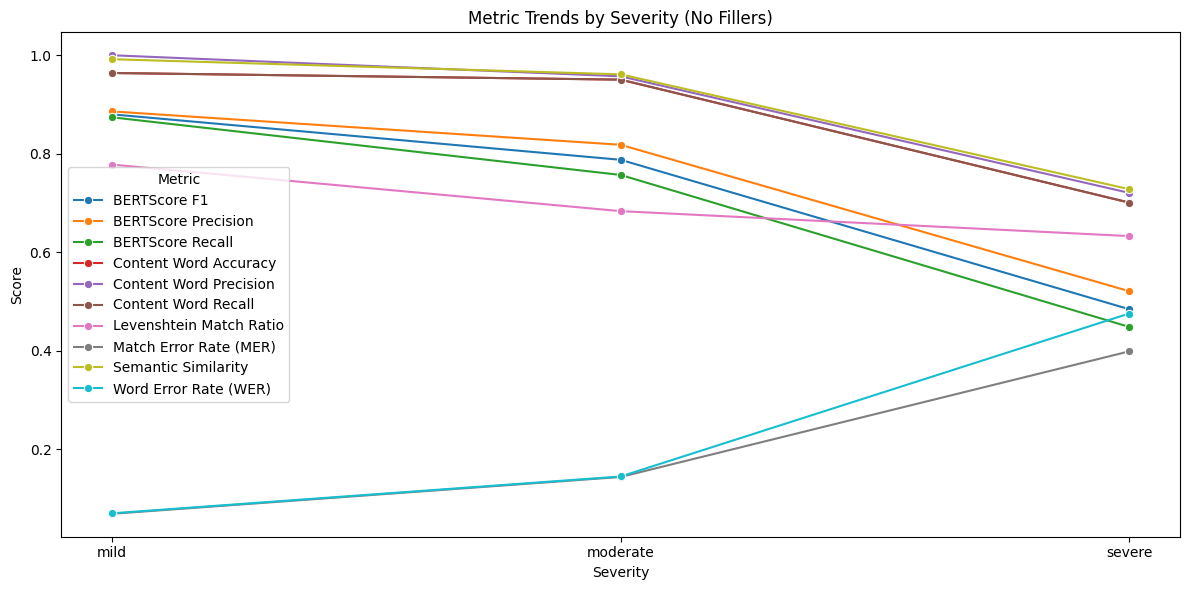

In [39]:
df_nf = df_long[df_long["Version"] == "No Fillers"]
metric_trend = df_nf.groupby(["Severity", "Metric"])["Score"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=metric_trend, x="Severity", y="Score", hue="Metric", marker="o")
plt.title("Metric Trends by Severity (No Fillers)")
plt.tight_layout()
plt.savefig("../results/vis/metric_trends.png", dpi=300)
plt.show()


##  Synthetic (Educational) vs Real Aphasia

In [35]:
# Define which videos are synthetic
synthetic_videos = ["metrics_9", "metrics_10"]

# Create new column in df_normalized
df_normalized["SourceType"] = ["synthetic" if v in synthetic_videos else "real" for v in df_normalized.index]

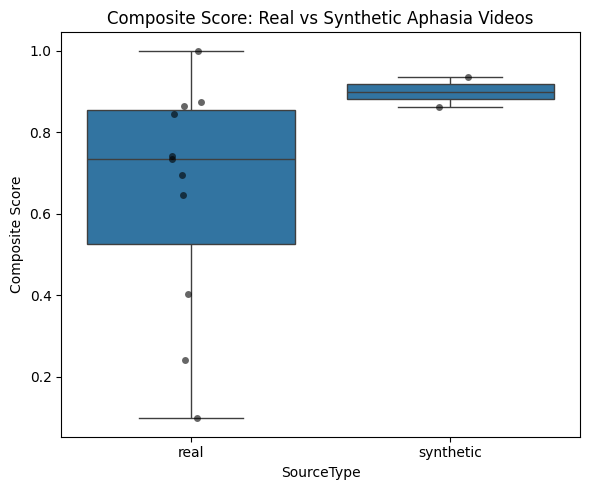

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplot of composite scores by source
plt.figure(figsize=(6, 5))
sns.boxplot(data=df_normalized, x="SourceType", y="Composite Score")
sns.stripplot(data=df_normalized, x="SourceType", y="Composite Score", color="black", alpha=0.6)
plt.title("Composite Score: Real vs Synthetic Aphasia Videos")
plt.tight_layout()
plt.savefig("../results/vis/synthetic.png", dpi=300)
plt.show()

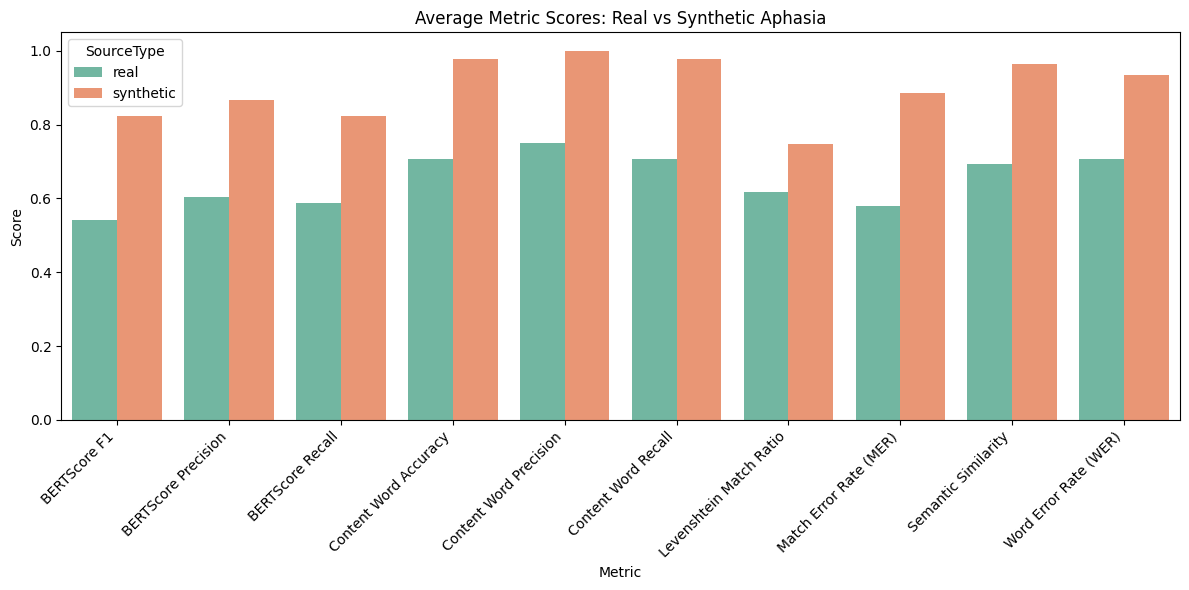

In [37]:
# Compute mean scores per metric and source type
df_melted = df_normalized.reset_index().melt(id_vars=["Video", "SourceType"], 
                                             value_vars=[col for col in df_normalized.columns if col != "Composite Score" and col != "SourceType"],
                                             var_name="Metric", value_name="Score")

# Group and plot
avg_metric_by_source = df_melted.groupby(["Metric", "SourceType"])["Score"].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_metric_by_source, x="Metric", y="Score", hue="SourceType", palette="Set2")
plt.title("Average Metric Scores: Real vs Synthetic Aphasia")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("../results/vis/synthetic_bar", dpi=300)
plt.show()

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1614194612.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


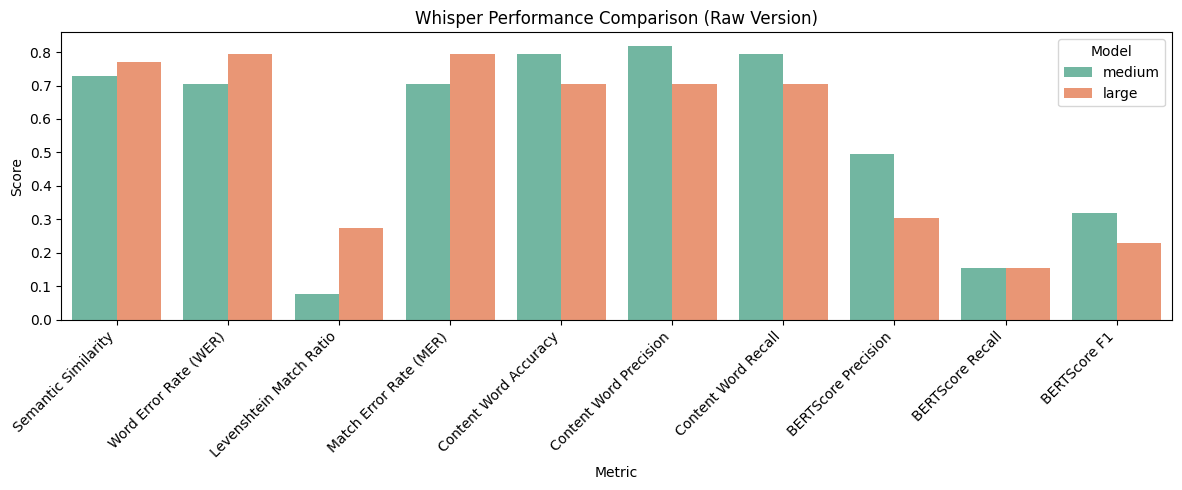

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1614194612.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


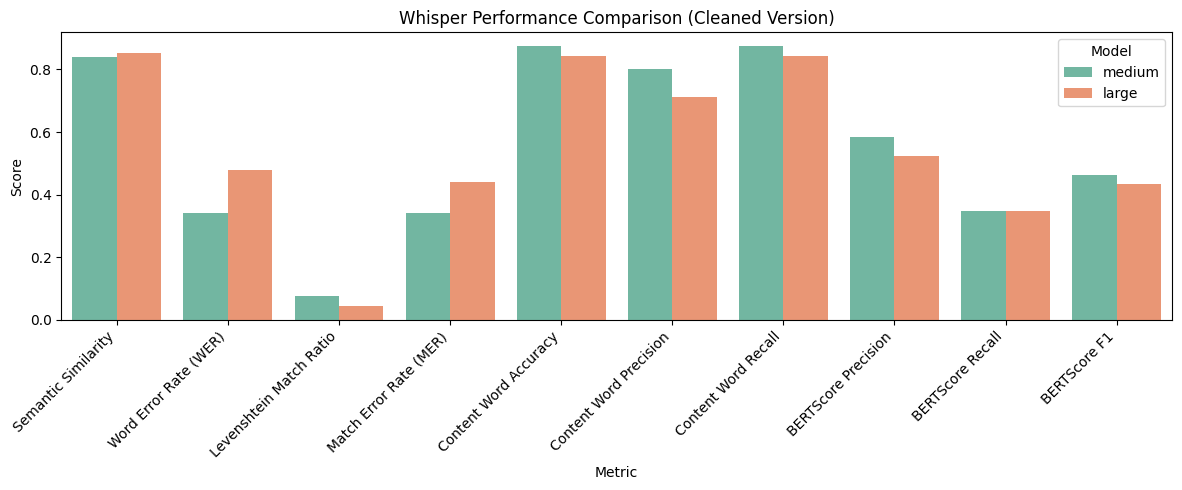

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1614194612.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


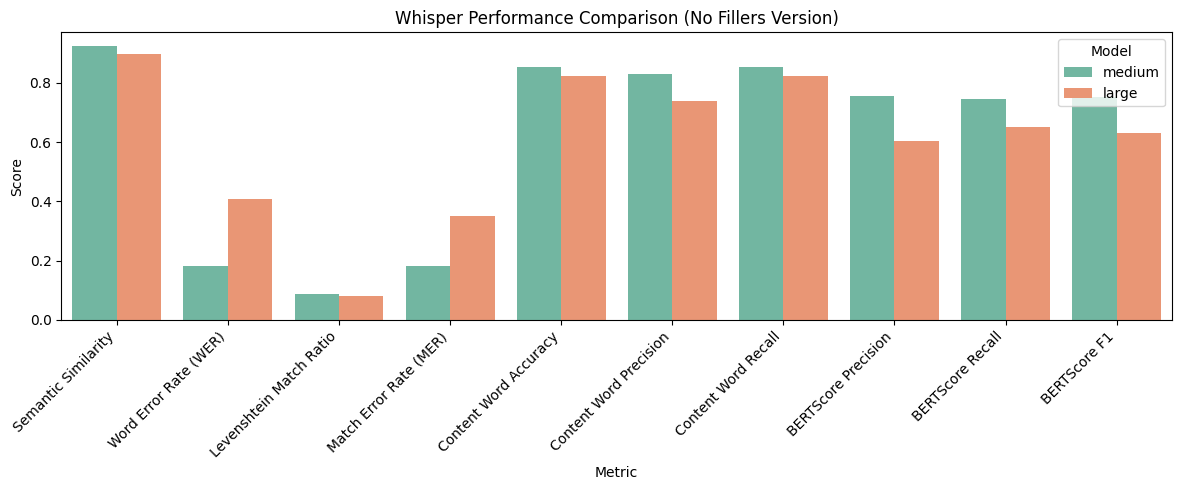

In [45]:
folder = "../results/metrics"
file_base = "metrics_1.csv"
file_large = "metrics_1_large.csv"

# Load and label
df_base = pd.read_csv(os.path.join(folder, file_base))
df_base["Model"] = "medium"

df_large = pd.read_csv(os.path.join(folder, file_large))
df_large["Model"] = "large"

# Combine and melt
df = pd.concat([df_base, df_large], ignore_index=True)

df_long = df.melt(
    id_vars=["Metric", "Model"],
    value_vars=["Raw", "Cleaned", "No Fillers"],
    var_name="Version",
    value_name="Score"
)

# Set consistent colors
colors = {"medium": "#66c2a5", "large": "#fc8d62"}

# Create one plot per version
versions = ["Raw", "Cleaned", "No Fillers"]

for version in versions:
    plt.figure(figsize=(12, 5))
    subset = df_long[df_long["Version"] == version]
    
    sns.barplot(
        data=subset,
        x="Metric",
        y="Score",
        hue="Model",
        palette=colors,
        ci=None
    )
    
    plt.title(f"Whisper Performance Comparison ({version} Version)")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"../results/vis/large_1_{version}", dpi=300)
    plt.show()

In [47]:
df_long

,Metric,Model,Version,Score
0,Semantic Similarity,medium,Raw,0.280
1,Word Error Rate (WER),medium,Raw,1.000
2,Levenshtein Match Ratio,medium,Raw,0.074
3,Match Error Rate (MER),medium,Raw,1.000
4,Content Word Accuracy,medium,Raw,0.167
5,Content Word Precision,medium,Raw,0.200
6,Content Word Recall,medium,Raw,0.167
7,BERTScore Precision,medium,Raw,0.215
8,BERTScore Recall,medium,Raw,-0.060
9,BERTScore F1,medium,Raw,0.075


C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1131634366.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Plotting: Raw, subset shape: (20, 4)
                    Metric   Model Version  Score
0      Semantic Similarity  medium     Raw  0.280
1    Word Error Rate (WER)  medium     Raw  1.000
2  Levenshtein Match Ratio  medium     Raw  0.074
3   Match Error Rate (MER)  medium     Raw  1.000
4    Content Word Accuracy  medium     Raw  0.167


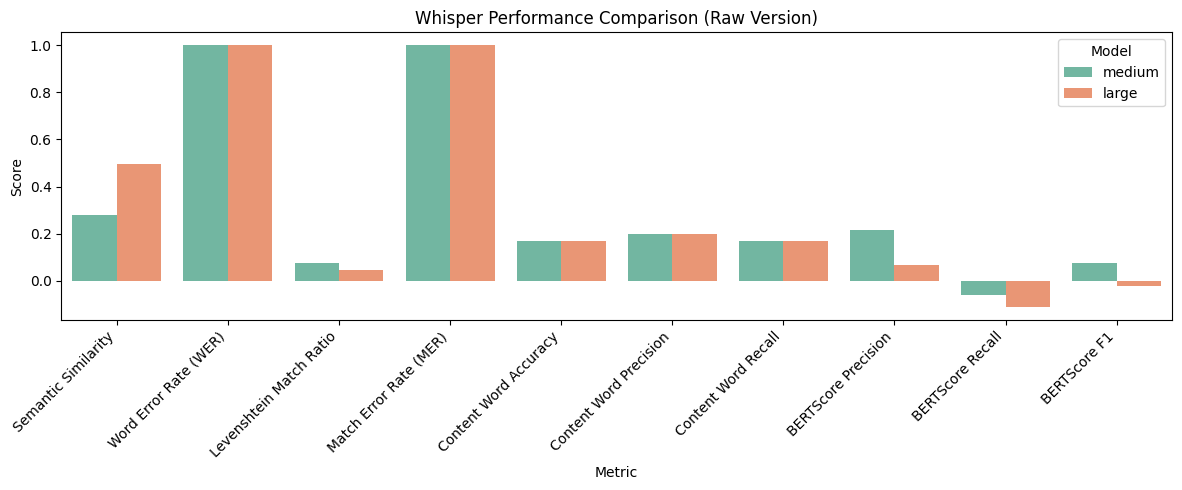

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1131634366.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Plotting: Cleaned, subset shape: (20, 4)
                     Metric   Model  Version  Score
20      Semantic Similarity  medium  Cleaned  0.322
21    Word Error Rate (WER)  medium  Cleaned  0.744
22  Levenshtein Match Ratio  medium  Cleaned  0.104
23   Match Error Rate (MER)  medium  Cleaned  0.727
24    Content Word Accuracy  medium  Cleaned  0.200


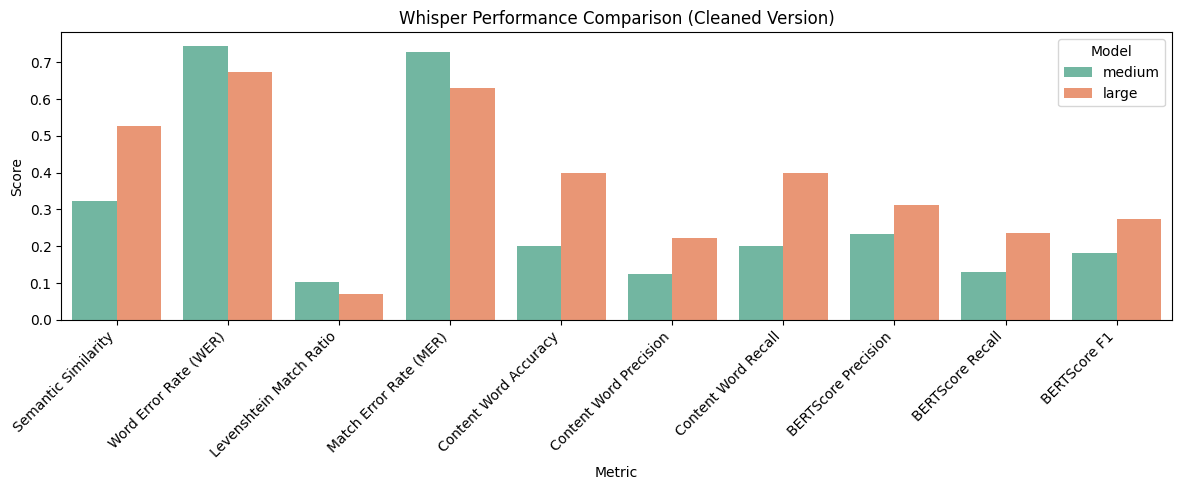

C:\Users\Мария\AppData\Local\Temp\ipykernel_16332\1131634366.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


Plotting: No Fillers, subset shape: (20, 4)
                     Metric   Model     Version  Score
40      Semantic Similarity  medium  No Fillers  0.325
41    Word Error Rate (WER)  medium  No Fillers  0.750
42  Levenshtein Match Ratio  medium  No Fillers  0.106
43   Match Error Rate (MER)  medium  No Fillers  0.714
44    Content Word Accuracy  medium  No Fillers  0.200


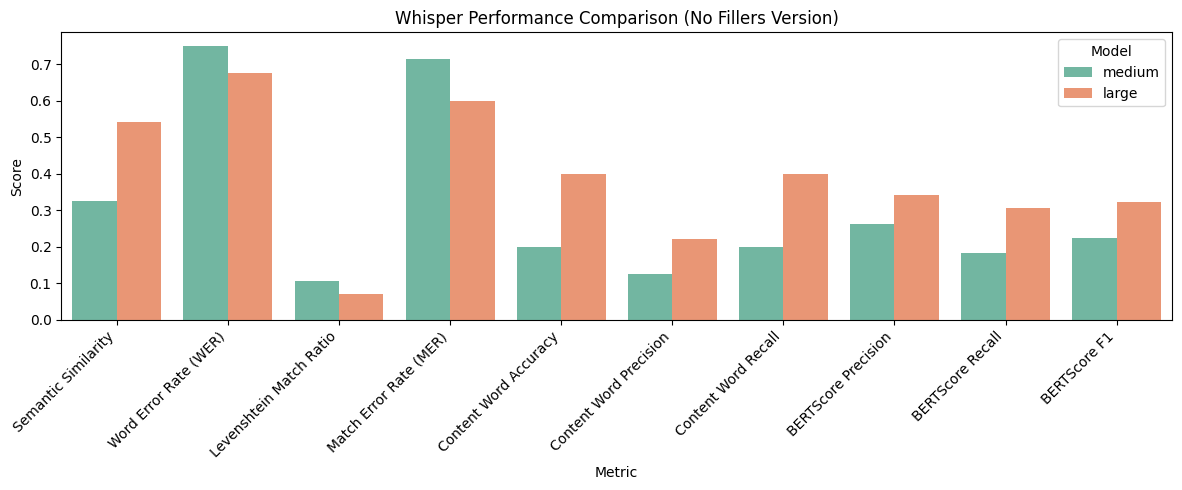

In [52]:
folder = "../results/metrics"
file_base = "metrics_2.csv"
file_large = "metrics_2_large.csv"

# Load and label
df_base = pd.read_csv(os.path.join(folder, file_base))
df_base["Model"] = "medium"

df_large = pd.read_csv(os.path.join(folder, file_large))
df_large["Model"] = "large"

# Combine and melt
df = pd.concat([df_base, df_large], ignore_index=True)

df_long = df.melt(
    id_vars=["Metric", "Model"],
    value_vars=["Raw", "Cleaned", "No Fillers"],
    var_name="Version",
    value_name="Score"
)

# Set consistent colors
colors = {"medium": "#66c2a5", "large": "#fc8d62"}

# Create one plot per version
versions = ["Raw", "Cleaned", "No Fillers"]

for version in versions:
    plt.figure(figsize=(12, 5))
    subset = df_long[df_long["Version"] == version]
    
    sns.barplot(
        data=subset,
        x="Metric",
        y="Score",
        hue="Model",
        palette=colors,
        ci=None
    )
    
    plt.title(f"Whisper Performance Comparison ({version} Version)")
    plt.ylabel("Score")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    print(f"Plotting: {version}, subset shape: {subset.shape}")
    print(subset.head())
    plt.savefig(f"../results/vis/large_2_{version}", dpi=300)
    plt.show()

In [50]:
df_base[["Metric", "Cleaned", "No Fillers"]]


,Metric,Cleaned,No Fillers
0,Semantic Similarity,0.322,0.325
1,Word Error Rate (WER),0.744,0.750
2,Levenshtein Match Ratio,0.104,0.106
3,Match Error Rate (MER),0.727,0.714
4,Content Word Accuracy,0.200,0.200
5,Content Word Precision,0.125,0.125
6,Content Word Recall,0.200,0.200
7,BERTScore Precision,0.232,0.262
8,BERTScore Recall,0.129,0.182
9,BERTScore F1,0.182,0.223


In [51]:
df_large[["Metric", "Cleaned", "No Fillers"]]

,Metric,Cleaned,No Fillers
0,Semantic Similarity,0.527,0.543
1,Word Error Rate (WER),0.674,0.675
2,Levenshtein Match Ratio,0.069,0.070
3,Match Error Rate (MER),0.630,0.600
4,Content Word Accuracy,0.400,0.400
5,Content Word Precision,0.222,0.222
6,Content Word Recall,0.400,0.400
7,BERTScore Precision,0.312,0.342
8,BERTScore Recall,0.236,0.305
9,BERTScore F1,0.275,0.324


In [53]:
print("Cleaned version comparison:")
print(df_long[df_long["Version"] == "Cleaned"].pivot(index="Metric", columns="Model", values="Score"))

print("\nNo Fillers version comparison:")
print(df_long[df_long["Version"] == "No Fillers"].pivot(index="Metric", columns="Model", values="Score"))


Cleaned version comparison:
Model                    large  medium
Metric                                
BERTScore F1             0.275   0.182
BERTScore Precision      0.312   0.232
BERTScore Recall         0.236   0.129
Content Word Accuracy    0.400   0.200
Content Word Precision   0.222   0.125
Content Word Recall      0.400   0.200
Levenshtein Match Ratio  0.069   0.104
Match Error Rate (MER)   0.630   0.727
Semantic Similarity      0.527   0.322
Word Error Rate (WER)    0.674   0.744

No Fillers version comparison:
Model                    large  medium
Metric                                
BERTScore F1             0.324   0.223
BERTScore Precision      0.342   0.262
BERTScore Recall         0.305   0.182
Content Word Accuracy    0.400   0.200
Content Word Precision   0.222   0.125
Content Word Recall      0.400   0.200
Levenshtein Match Ratio  0.070   0.106
Match Error Rate (MER)   0.600   0.714
Semantic Similarity      0.543   0.325
Word Error Rate (WER)    0.675   0.750
